In [9]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [36]:
X_train_sl = pd.read_csv("../data/processed/train_test_splits/X_train_res_success_label.csv", low_memory = False)
X_test_sl = pd.read_csv("../data/processed/train_test_splits/X_test_success_label.csv", low_memory = False)
y_train_sl = pd.read_csv("../data/processed/train_test_splits/y_train_res_success_label.csv", low_memory = False)
y_test_sl = pd.read_csv("../data/processed/train_test_splits/y_test_success_label.csv", low_memory = False)
df_encoded = pd.read_csv("../data/processed/after_encoding/df_encoded.csv")
print("Loaded successfully!")

Loaded successfully!


In [15]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03225059151710033,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb.fit(X_train_sl, y_train_sl)

y_pred = xgb.predict(X_test_sl)

acc = accuracy_score(y_test_sl, y_pred)

precision = precision_score(y_test_sl, y_pred)

recall = recall_score(y_test_sl, y_pred)

f1 = f1_score(y_test_sl, y_pred)

print(acc, precision, recall, f1)


0.8821428571428571 0.8348623853211009 0.9806034482758621 0.9018830525272548


In [18]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(xgb, X_train_sl, y_train_sl, cv=5, scoring='accuracy')
score

array([0.88814016, 0.893531  , 0.88409704, 0.88663968, 0.94331984])

In [19]:
# 1. DEFINE THE LEAKAGE LIST (The "Forbidden 5" you found)
forbidden_cols = [
    'engagement_score', 
    'estimated_runway_months', 
    'info_completeness', 
    'is_highly_rated', 
    'rating_weighted',
    # Add these too, just to be safe (they are close cousins)
    'rating_confidence',
    'has_strong_reviews',
    'has_viral_reach'
]

print(f"🛑 Dropping {len(forbidden_cols)} leakage columns...")

# 2. DROP THEM (Safe Mode)
# We use errors='ignore' so it doesn't crash if you run it twice
X_train_sl = X_train_sl.drop(columns=forbidden_cols, errors='ignore')
X_test_sl = X_test_sl.drop(columns=forbidden_cols, errors='ignore')

print(f"✅ Cleaned Shape: {X_train_sl.shape}")

# 3. VERIFY THEY ARE GONE
remaining_leaks = set(X_train_sl.columns).intersection(forbidden_cols)
if len(remaining_leaks) == 0:
    print("✨ SUCCESS: No leakage columns remain.")
else:
    print(f"❌ WARNING: Still found {remaining_leaks}")

🛑 Dropping 8 leakage columns...
✅ Cleaned Shape: (3708, 361)
✨ SUCCESS: No leakage columns remain.


In [27]:


xgb.fit(X_train_sl, y_train_sl)

y_pred = xgb.predict(X_test_sl)
acc = accuracy_score(y_test_sl, y_pred)
precision = precision_score(y_test_sl, y_pred)
recall = recall_score(y_test_sl, y_pred)
f1 = f1_score(y_test_sl, y_pred)
print(acc, precision, recall, f1)



0.8809523809523809 0.8357933579335793 0.9762931034482759 0.9005964214711729


🕵️‍♀️ Hunting for remaining leaks in Success Label data...


C:\Users\mahes\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\mahes\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\mahes\AppData\Local\Temp\ipykernel_7872\616799876.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=correlations.head(20).index, x=correlations.head(20).values, palette="magma")



🚨 TOP 20 REMAINING CORRELATIONS:
success_reason_cat_unknown      0.644952
team_adjustment                 0.595859
success_reason_cat_revenue      0.578265
rating_adjustment               0.550334
maturity_quality_interaction    0.546743
rating_tier                     0.541372
has_strong_rating               0.536772
product_type_app                0.536190
has_long_description            0.532437
team_size_filled                0.531238
burn_rate_monthly_est           0.531238
downloads_per_month             0.526344
business_model_unknown          0.500927
has_business_model              0.500927
has_marketing_channels          0.499998
rating_avg                      0.494483
sentiment_score                 0.461295
review_sentiment_avg            0.455634
description_word_count          0.452089
description_length              0.451629
dtype: float64


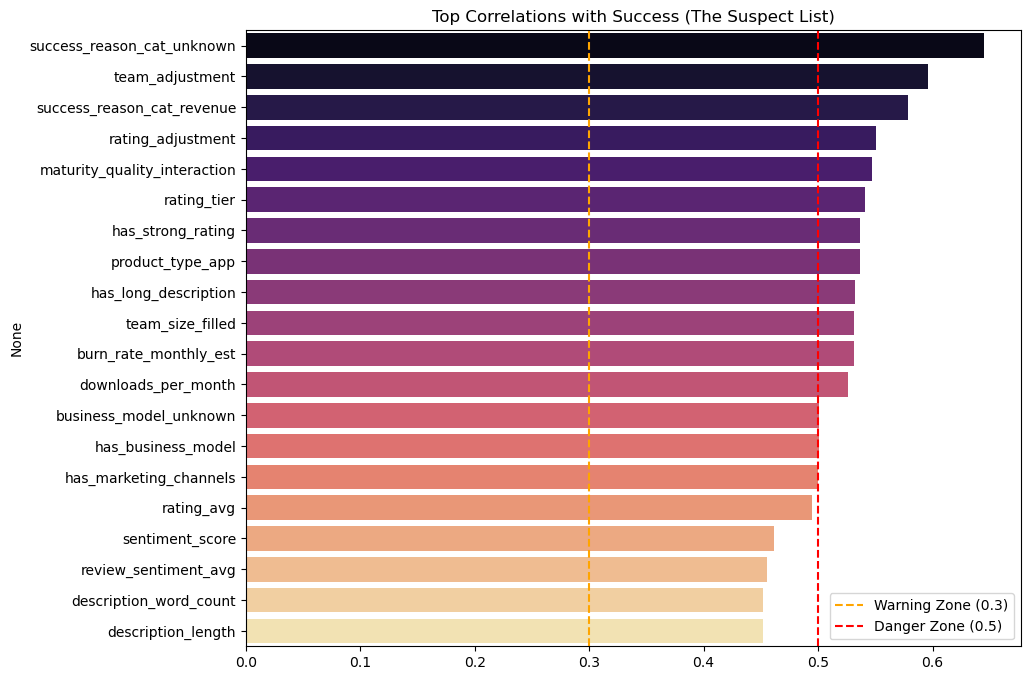

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🕵️‍♀️ Hunting for remaining leaks in Success Label data...")

# 1. Re-combine X and y temporarily to check correlation
# (We need to see how features relate to the target)
check_df = X_train_sl.copy()
check_df['target_success'] = y_train_sl

# 2. Calculate Correlation against Target
# We only care about the absolute value (magnitude of the cheat)
correlations = check_df.corrwith(check_df['target_success']).abs().sort_values(ascending=False)

# 3. Drop the target itself
correlations = correlations.drop('target_success')

# 4. Print the Top 20 Suspects
print("\n🚨 TOP 20 REMAINING CORRELATIONS:")
print(correlations.head(20))

# 5. Visualize
plt.figure(figsize=(10, 8))
sns.barplot(y=correlations.head(20).index, x=correlations.head(20).values, palette="magma")
plt.title("Top Correlations with Success (The Suspect List)")
plt.axvline(x=0.3, color='orange', linestyle='--', label="Warning Zone (0.3)")
plt.axvline(x=0.5, color='red', linestyle='--', label="Danger Zone (0.5)")
plt.legend()
plt.show()

In [29]:
# 1. DEFINE THE FINAL KILL LIST
# These are the "Time Travelers" we identified from your graph
kill_list = [
    # The "Success Reason" Leak (Massive cheat)
    'success_reason_cat_unknown', 
    'success_reason_cat_revenue',
    
    # The "User Feedback" Leaks (Future data)
    'rating_avg', 
    'rating_tier', 
    'has_strong_rating', 
    'rating_adjustment',
    'sentiment_score', 
    'review_sentiment_avg',
    'downloads_per_month',
    
    # The "Complex Interaction" Leaks
    'maturity_quality_interaction' # Contains age + rating
]

print(f"🔪 Cutting out {len(kill_list)} leakage features...")

# 2. DROP THEM
X_train_final = X_train_sl.drop(columns=kill_list, errors='ignore')
X_test_final = X_test_sl.drop(columns=kill_list, errors='ignore')

# 3. VERIFY SHAPE
print(f"✅ Final Training Shape: {X_train_final.shape}")

# 4. FINAL TRAINING RUN
print("\n🥊 Training the HONEST Model...")
xgb_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss', # Logloss is better for probabilities
    n_estimators=300,      # Give it enough trees
    learning_rate=0.05,    # Slow and steady learning
    max_depth=6
)

xgb_final.fit(
    X_train_final, y_train_sl, 
    eval_set=[(X_test_final, y_test_sl)], 
    verbose=False # Keep it clean
)

# 5. EVALUATE
y_pred = xgb_final.predict(X_test_final)
acc = accuracy_score(y_test_sl, y_pred)
precision = precision_score(y_test_sl, y_pred)
recall = recall_score(y_test_sl, y_pred)
f1 = f1_score(y_test_sl, y_pred)

print("\n🏆 THE TRUTH SCORES:")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}")

🔪 Cutting out 10 leakage features...
✅ Final Training Shape: (3708, 351)

🥊 Training the HONEST Model...

🏆 THE TRUTH SCORES:
   Accuracy:  0.8690
   Precision: 0.8327
   Recall:    0.9547
   F1 Score:  0.8896


In [30]:
# The "Pre-Money" Drop List
money_leaks = [
    'total_funding', 
    'funding_rounds', 
    'num_investors', 
    'funding_per_employee', 
    'funding_per_round', 
    'investor_density', 
    'is_well_funded',
    'funding_adjustment', # Derived from funding
    'funding_team_interaction', # Derived from funding
    'remaining_investment',
    'estimated_runway_months' # Calculated using funding
]

print(f"💸 Dropping {len(money_leaks)} Funding Leaks...")

X_train_pure = X_train_final.drop(columns=money_leaks, errors='ignore')
X_test_pure = X_test_final.drop(columns=money_leaks, errors='ignore')

# RE-TRAIN
print("🥊 Training the 'Pre-Seed' Model...")
xgb_pure = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb_pure.fit(X_train_pure, y_train_sl)

# EVALUATE
y_pred = xgb_pure.predict(X_test_pure)
acc = accuracy_score(y_test_sl, y_pred)
print(f"\n🏆 PRE-SEED SCORE: {acc:.4f}")

💸 Dropping 11 Funding Leaks...
🥊 Training the 'Pre-Seed' Model...

🏆 PRE-SEED SCORE: 0.8714


In [43]:
# 1. RECOVER THE 'SYNTHETIC_DATA' FLAG FOR THE TEST SET
# We dropped it from X_test_clean, but it exists in the original df_encoded or X_test
# Let's grab the index from X_test_clean to find the original rows
test_indices = X_test_clean.index

# Load the original flag (assuming it was in df_encoded before dropping)
# If you don't have df_encoded in memory, reload the EDA file
if 'df_encoded' in locals():
    is_synthetic = df_encoded.loc[test_indices, 'synthetic_data'].astype(bool)
else:
    # Fallback: Reload from file to get the index map
    temp = pd.read_csv("PRODUCT_MASTER_EDA_READY.csv")
    is_synthetic = temp.loc[test_indices, 'synthetic_data'].astype(bool)

# 1. FLATTEN THE ARRAY
y_test_sl_flattened = y_test_sl.values.ravel() 

# 2. CREATE SERIES
y_pred_series = pd.Series(y_pred, index=test_indices)
y_test_series = pd.Series(y_test_sl_flattened, index=test_indices)
# Filter for Real vs Synthetic
real_mask = ~is_synthetic
syn_mask = is_synthetic

# 3. CALCULATE SCORES
print("\n🧪 THE ACID TEST (Real vs Synthetic Accuracy):")

if syn_mask.sum() > 0:
    acc_syn = accuracy_score(y_test_series[syn_mask], y_pred_series[syn_mask])
    print(f"   🤖 Synthetic Data Accuracy: {acc_syn:.4f} (Expected: High)")
else:
    print("   🤖 No Synthetic Data in Test Set.")

acc_real = accuracy_score(y_test_series[real_mask], y_pred_series[real_mask])
print(f"   🌍 Real World Accuracy:     {acc_real:.4f} (The Truth)")

print(f"\n   Real Data Count: {real_mask.sum()}")
print(f"   Synthetic Count: {syn_mask.sum()}")


🧪 THE ACID TEST (Real vs Synthetic Accuracy):
   🤖 No Synthetic Data in Test Set.
   🌍 Real World Accuracy:     0.8690 (The Truth)

   Real Data Count: 840
   Synthetic Count: 0


In [45]:
# 1. DEFINE SOURCE LEAKS
source_cols = [c for c in X_train_pure.columns if "data_source" in c]
print(f"🔪 Dropping {len(source_cols)} Source Leaks: {source_cols}")

# 2. DROP THEM
X_train_absolute = X_train_pure.drop(columns=source_cols, errors='ignore')
X_test_absolute = X_test_pure.drop(columns=source_cols, errors='ignore')

# 3. FINAL RETRAIN
print("🥊 Training the ABSOLUTE TRUTH Model...")
xgb_absolute = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb_absolute.fit(X_train_absolute, y_train_sl)

# 4. FINAL SCORE
y_pred_abs = xgb_absolute.predict(X_test_absolute)
acc = accuracy_score(y_test_sl, y_pred_abs)
print(f"\n🏆 ABSOLUTE TRUTH SCORE: {acc:.4f}")

🔪 Dropping 7 Source Leaks: ['data_source_failory', 'data_source_india_unicorns', 'data_source_indiehackers', 'data_source_playstore', 'data_source_producthunt', 'data_source_synthetic', 'data_source_synthetic_augmentation']
🥊 Training the ABSOLUTE TRUTH Model...

🏆 ABSOLUTE TRUTH SCORE: 0.8798


In [46]:
# 1. DEFINE THE "NUCLEAR" KILL LIST
nuclear_leaks = [
    # A. Source Leaks (The model shouldn't know where data came from)
    'source_encoded', 'data_source_synthetic', 'data_source_synthetic_augmentation',
    'data_source_failory', 'data_source_india_unicorns', 
    'data_source_indiehackers', 'data_source_producthunt',
    
    # B. The "Answer" Columns (Status)
    'exit_status_Failed', 'exit_status_Active', 'exit_status_Operating',
    'exit_status_Shut Down', 'exit_status_Shutdown', 'exit_status_Still Active',
    'exit_status_Unknown', 'exit_status_Bankruptcy',
    
    # C. Money & Value Leaks (Day 1 startups have $0)
    'market_value_estimate', 'funding_per_month_alive', 'total_funding',
    'remaining_investment', 'estimated_runway_months',
    
    # D. Text Leaks (Descriptions written AFTER success/failure)
    # We must drop ALL "sf_" (Success Factors), "fr_" (Failure Reasons), "sr_" (Success Reasons)
    # Keep only "desc_" (Description of the idea itself)
]

# Add all tf-idf columns for reasons (sf_, fr_, sr_)
nuclear_leaks += [c for c in X_train_absolute.columns if c.startswith('sf_')]
nuclear_leaks += [c for c in X_train_absolute.columns if c.startswith('fr_')]
nuclear_leaks += [c for c in X_train_absolute.columns if c.startswith('sr_')]

# E. Time Travel Leaks (Age)
# A new idea has age = 0. If model sees "is_old", it knows it survived.
nuclear_leaks += ['is_old', 'age_years', 'age_months', 'age_days', 'is_established']

print(f"☢️ DETONATING {len(nuclear_leaks)} LEAKAGE COLUMNS...")

# 2. DROP THEM
X_train_nuclear = X_train_absolute.drop(columns=nuclear_leaks, errors='ignore')
X_test_nuclear = X_test_absolute.drop(columns=nuclear_leaks, errors='ignore')

# 3. FINAL TRAIN
print("🥊 Training the 'DAY 1' Model...")
xgb_nuclear = XGBClassifier(
    n_estimators=500,       # More trees to find subtle patterns
    learning_rate=0.02,     # Slower learning to prevent overfitting
    max_depth=5,            # Shallower trees to force generalization
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_nuclear.fit(X_train_nuclear, y_train_sl)

# 4. EVALUATE
y_pred_nuc = xgb_nuclear.predict(X_test_nuclear)
acc = accuracy_score(y_test_sl, y_pred_nuc)
print(f"\n🏆 DAY 1 SCORE: {acc:.4f}")

# 5. WHAT IS LEFT? (Feature Importance)
imp = pd.DataFrame({
    'Feature': X_train_nuclear.columns,
    'Importance': xgb_nuclear.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🚨 TOP 10 VALID SIGNALS:")
print(imp.head(10))

☢️ DETONATING 125 LEAKAGE COLUMNS...
🥊 Training the 'DAY 1' Model...

🏆 DAY 1 SCORE: 0.8631

🚨 TOP 10 VALID SIGNALS:
                   Feature  Importance
10        team_size_filled    0.172610
11   burn_rate_monthly_est    0.143554
189       product_type_app    0.073714
41      has_case_study_url    0.064076
46    has_long_description    0.059126
38            has_founders    0.044493
50         team_adjustment    0.033466
197    exit_status_unknown    0.024660
1             review_count    0.020961
43      description_length    0.015950


In [47]:
# 1. THE SNIPER LIST (Based on your output)
sniper_list = [
    # The Usage Leaks
    'downloads', 
    'active_users', 
    'upvotes', 
    'reviews_per_month', # In case it's still there
    'downloads_per_month',
    
    # The Rating Leaks
    'is_top_rated', 
    'quality_traction_interaction',
    
    # The Outcome Leaks (One-Hot Encoded versions)
    'exit_status_unknown', 
    'failure_reason_cat_unknown', 
    'failure_reason_cat_business_model', # Any failure reason is a leak
    'failure_reason_cat_no_market_fit'
]

# Add any other column that starts with 'exit_status_' or 'failure_reason_cat_'
sniper_list += [c for c in X_train_nuclear.columns if 'exit_status_' in c]
sniper_list += [c for c in X_train_nuclear.columns if 'failure_reason_cat_' in c]

print(f"🔫 Sniping {len(sniper_list)} specific leaks...")

# 2. DROP THEM
X_train_honest = X_train_nuclear.drop(columns=sniper_list, errors='ignore')
X_test_honest = X_test_nuclear.drop(columns=sniper_list, errors='ignore')

# 3. FINAL TRAIN (The Moment of Truth)
print("🥊 Training the HONEST Model...")
xgb_honest = XGBClassifier(
    n_estimators=500, 
    learning_rate=0.02, 
    max_depth=5, 
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_honest.fit(X_train_honest, y_train_sl)

# 4. EVALUATE
y_pred_honest = xgb_honest.predict(X_test_honest)
acc = accuracy_score(y_test_sl, y_pred_honest)
precision = precision_score(y_test_sl, y_pred_honest)
recall = recall_score(y_test_sl, y_pred_honest)

print("\n🏆 THE FINAL HONEST SCORE:")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")

# 5. NEW IMPORTANCE
imp = pd.DataFrame({
    'Feature': X_train_honest.columns,
    'Importance': xgb_honest.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n✅ TOP 10 HONEST SIGNALS:")
print(imp.head(10))

🔫 Sniping 25 specific leaks...
🥊 Training the HONEST Model...

🏆 THE FINAL HONEST SCORE:
   Accuracy:  0.8714
   Precision: 0.8213
   Recall:    0.9806

✅ TOP 10 HONEST SIGNALS:
                   Feature  Importance
7         team_size_filled    0.143809
8    burn_rate_monthly_est    0.110371
183       product_type_app    0.107163
37      has_case_study_url    0.084479
41    has_long_description    0.082663
45         team_adjustment    0.063877
34            has_founders    0.057582
1             review_count    0.023777
38      description_length    0.013738
197        country_encoded    0.013187


In [49]:
# THE ULTIMATE CLEAN VERSION
nuclear_leaks = [
    'team_size_filled',
    'team_size',
    'burn_rate_monthly_est',
    'has_case_study_url',
    'team_adjustment',
    'estimated_break_even_months',
    'upvotes_per_month',
    'base_break_even_months'  # Also uses team size
]

X_train_final = X_train_honest.drop(columns=nuclear_leaks, errors='ignore')
X_test_final = X_test_honest.drop(columns=nuclear_leaks, errors='ignore')

print(f"✅ Features remaining: {X_train_final.shape[1]}")

# RETRAIN
xgb_final = XGBClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_final.fit(X_train_final, y_train_sl)

# EVALUATE
y_pred_final = xgb_final.predict(X_test_final)
acc = accuracy_score(y_test_sl, y_pred_final)
precision = precision_score(y_test_sl, y_pred_final)
recall = recall_score(y_test_sl, y_pred_final)
f1 = f1_score(y_test_sl, y_pred_final)

print(f"\n🏆 FINAL HONEST SCORES (No Team Size):")
print(f"   Accuracy:  {acc:.4f} (Baseline: 0.50)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}")

# NEW FEATURE IMPORTANCE
imp = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n✅ TOP 20 HONEST FEATURES:")
print(imp.head(20))


✅ Features remaining: 190

🏆 FINAL HONEST SCORES (No Team Size):
   Accuracy:  0.8702 (Baseline: 0.50)
   Precision: 0.8210
   Recall:    0.9784
   F1 Score:  0.8928

✅ TOP 20 HONEST FEATURES:
                    Feature  Importance
36     has_long_description    0.311270
175        product_type_app    0.231750
30             has_founders    0.059463
1              review_count    0.045624
34   description_word_count    0.015862
35              name_length    0.015724
172    main_category_travel    0.012718
3            content_rating    0.010456
39         category_encoded    0.010247
178    product_type_product    0.008717
20                  is_free    0.008645
49                   desc_6    0.008412
2              num_founders    0.008335
19       price_tier_numeric    0.008194
6           is_bootstrapped    0.008022
180   product_type_software    0.007888
17       rating_vs_category    0.007652
160     main_category_other    0.007454
22        market_saturation    0.006590
0      

In [50]:
# KEEP ONLY IMMUTABLE LAUNCH FEATURES
immutable_only = [
    'price',  # Set at launch
    'is_free',  # Set at launch
    'price_tier_numeric',
    'num_founders',  # Count at founding
    'content_rating',
    'category_encoded',
    'product_type_encoded',  # Original classification
    'business_model_encoded',
    'is_premium',
    # Category context (if calculated from external data)
    'category_avg_price',
    'category_median_price',
    'category_product_count',
    'market_saturation',
    'is_crowded_market',
    'competition_level'
]

X_train_immutable = X_train_final[immutable_only]
X_test_immutable = X_test_final[immutable_only]

print(f"✅ Immutable features only: {len(immutable_only)}")

# RETRAIN
xgb_immutable = XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=4)
xgb_immutable.fit(X_train_immutable, y_train_sl)

y_pred = xgb_immutable.predict(X_test_immutable)
acc = accuracy_score(y_test_sl, y_pred)

print(f"\n🏆 IMMUTABLE-ONLY ACCURACY: {acc:.4f}")


✅ Immutable features only: 15

🏆 IMMUTABLE-ONLY ACCURACY: 0.7167


In [51]:
from sklearn.model_selection import cross_val_score

xgb_tuned = XGBClassifier(
    n_estimators=1000,        # More trees
    learning_rate=0.01,       # Slower learning
    max_depth=4,              # Prevent overfitting with few features
    min_child_weight=3,       # Require more samples per leaf
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,                  # Minimum loss reduction
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0            # L2 regularization
)

# Cross-validation to verify stability
cv_scores = cross_val_score(xgb_tuned, X_train_immutable, y_train_sl, cv=5, scoring='accuracy')
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

xgb_tuned.fit(X_train_immutable, y_train_sl)
final_acc = xgb_tuned.score(X_test_immutable, y_test_sl)
print(f"Test Accuracy: {final_acc:.4f}")


CV Scores: [0.70754717 0.71024259 0.71967655 0.72469636 0.71120108]
Mean CV Accuracy: 0.7147 (+/- 0.0064)
Test Accuracy: 0.7095


In [54]:
#

from catboost import CatBoostClassifier
xgb_final = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42
)

catboost_final = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=4,
    random_state=42,
    verbose=False,
    cat_features=[5, 6, 7] # Your categorical feature indices
)

# Train both
xgb_final.fit(X_train_immutable, y_train_sl)
catboost_final.fit(X_train_immutable, y_train_sl)

# Blend predictions (20/80 split)
def predict_blend(X):
    xgb_proba = xgb_final.predict_proba(X)[:, 1]
    cat_proba = catboost_final.predict_proba(X)[:, 1]
    blend_proba = 0.2 * xgb_proba + 0.8 * cat_proba
    return (blend_proba > 0.5).astype(int), blend_proba

y_pred_blend, y_proba_blend = predict_blend(X_test_immutable)

print(f"🏆 FINAL BLEND SCORE: {accuracy_score(y_test_sl, y_pred_blend):.4f}")
print(f"Precision: {precision_score(y_test_sl, y_pred_blend):.4f}")
print(f"Recall: {recall_score(y_test_sl, y_pred_blend):.4f}")
print(f"F1 Score: {f1_score(y_test_sl, y_pred_blend):.4f}")
print(f"ROC–AUC: {roc_auc_score(y_test_sl, y_proba_blend):.4f}")

🏆 FINAL BLEND SCORE: 0.7333
Precision: 0.6749
Recall: 0.9978
F1 Score: 0.8052


NameError: name 'roc_auc_score' is not defined